# RTMA Fuel Moisture Analysis — Local Pipeline

Consumes the NWS RTMA hourly pyrome-mean CSVs exported from GEE
(see `00b_RTMA-EMC.ipynb`) and produces per-pyrome dead and live
fuel moisture for FlamMap scenario inputs.

**Pipeline summary**
1. Load all yearly RTMA CSVs → hourly frame
2. NFDRS78 exponential lag (hourly dt=1 h) → FM1 / FM10 / FM100
3. Collapse to daily peak-hour (14:00 LST)
4. GSI-based live FM → FM_herb / FM_woody
5. Join dead + live into one daily frame
6. QA plots (time series, seasonal climatology, precip rebound)
7. FlamMap scenario cache via `build_flammap_scenario_cache(dead_fm_source='rtma')`
8. Summary table

**Sources:** `fb_tools.weather.rtma`, `fb_tools.weather.gridmet`, `fb_tools.weather.hrrr`

**Live FM calibration caveat:** Jolly et al. (2005) GSI thresholds were
calibrated for temperate/boreal vegetation. In CO's semi-arid fire season,
VPD routinely exceeds the 4100 Pa 'limiting' bound, compressing GSI toward
zero and keeping FM_herb near dormant (30%). This is a known limitation
of the approach; see `CLAUDE.md` GridMET ERC climatology notes.

In [1]:
from pathlib import Path
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from fb_tools.weather.rtma import (
    load_rtma_csv,
    build_rtma_dead_fm,
    build_rtma_live_fm,
    collapse_to_peak_hour,
)
from fb_tools.weather.gridmet import load_gridmet_csv, build_flammap_scenario_cache
from fb_tools.weather.hrrr import wind_percentiles_from_cell_cache
from fb_tools import pyrome_centroids

# ── region config ─────────────────────────────────────────────────────────
# Must match the REGION + pyrome set used in the GEE exports (00b_RTMA-EMC and
# 00a_gridMET-ERC). InterWest = CO (9) + R4 forests (3).
REGION     = "InterWest"
PYROME_IDS = [42, 43, 45, 46, 47, 52, 53, 56, 128, 14, 16, 44]

# ── paths (relative to this notebook's location: code/notebooks/) ──────────
REPO = Path("../..").resolve()
# Drop the monthly RTMA CSVs downloaded from Drive here — one folder PER REGION
# so the 12-pyrome InterWest monthly files never mix with the old 9-pyrome CO
# exports (load_rtma_csv globs every *.csv in the folder).
RTMA_DIR    = REPO / "data/weather/pyrome_emc/RTMA_MONTHLY"
GRIDMET_CSV = REPO / f"data/tabular/raw/weather/GRIDMET_ERC_InterWest_pyromes.csv"
WIND_DIR    = REPO / "data/weather/pyrome_wind"
BASELINE_DIR = REPO / "data/weather/flammap"          # existing GridMET-based JSONs
OUT_DIR     = REPO / "data/weather/flammap_rtma"
OUT_DIR.mkdir(parents=True, exist_ok=True)

projdir = Path.cwd().parents[1]   # moves up two, outside code directory
print(f"Project directory set to: {projdir}")

# ── constants ───────────────────────────────────────────────────────────────
TZ_OFF  = -7.0   # MST year-round — CO, UT, and Payette/ID are all Mountain Time
PEAK_HR = 14     # 14:00 LST peak fire hour

# Per-pyrome centroid latitude for daylength/GSI. The InterWest set spans
# ~36–45°N, so a single scalar latitude is no longer adequate (was CO_LAT=39.5).
# Derive from the CONUS pyromes layer; fall back to a precomputed dict if that
# layer isn't on this machine.
PYROMES_SHP = Path(
    "/Users/mcc/Library/CloudStorage/Box-Box/MCC/data/boundaries/pyromes/Pyromes_CONUS_20200206.shp"
)
try:
    _cent = pyrome_centroids(PYROMES_SHP, ids=PYROME_IDS, id_col="PYROME")
    LAT_BY_PYROME = {k: round(v[0], 2) for k, v in _cent.items()}
except Exception as e:
    print(f"  pyrome_centroids unavailable ({e}); using precomputed latitudes")
    LAT_BY_PYROME = {'42': 37.89, '43': 39.92, '45': 39.58, '46': 40.49, '47': 37.08,
                     '52': 38.16, '53': 36.43, '56': 39.79, '128': 42.02,
                     '14': 44.89, '16': 44.80, '44': 39.78}

print(f"REGION    : {REGION}  ({len(PYROME_IDS)} pyromes)")
print(f"RTMA dir  : {RTMA_DIR}")
print(f"Output dir: {OUT_DIR}")
print(f"CSV files : {len(list(RTMA_DIR.glob('*.csv'))) if RTMA_DIR.exists() else 0}")
print(f"lat range : {min(LAT_BY_PYROME.values())}–{max(LAT_BY_PYROME.values())}°N")

Project directory set to: /Users/mcc/Library/CloudStorage/Box-Box/MCC/fire_modeling/FM_PythonWrapper
REGION    : InterWest  (12 pyromes)
RTMA dir  : /Users/mcc/Library/CloudStorage/Box-Box/MCC/fire_modeling/FM_PythonWrapper/data/weather/pyrome_emc/RTMA_MONTHLY
Output dir: /Users/mcc/Library/CloudStorage/Box-Box/MCC/fire_modeling/FM_PythonWrapper/data/weather/flammap_rtma
CSV files : 105
lat range : 36.43–44.89°N


## 1. Load RTMA hourly data

In [2]:
rtma_hr = load_rtma_csv(RTMA_DIR)

print(f"Shape          : {rtma_hr.shape}")
print(f"Date range     : {rtma_hr['datetime_utc'].min()} → {rtma_hr['datetime_utc'].max()}")
print(f"Pyromes        : {sorted(rtma_hr['pyrome_id'].unique())}")
print(f"Null counts    :")
print(rtma_hr.isnull().sum().to_string())

rtma_hr.head(3)

Shape          : (911568, 7)
Date range     : 2011-04-01 00:00:00 → 2025-10-31 23:00:00
Pyromes        : [14, 16, 42, 43, 44, 45, 46, 47, 52, 53, 56, 128]
Null counts    :
pyrome_id       0
datetime_utc    0
tmp_f           0
rh_pct          0
emc_pct         0
vpd_pa          0
pcp_mm_hr       0


,pyrome_id,datetime_utc,tmp_f,rh_pct,emc_pct,vpd_pa,pcp_mm_hr
0,14,2011-04-01 00:00:00,39.249294,83.891782,19.694918,158.067692,0.0
1,14,2011-04-01 01:00:00,38.540918,84.92883,20.099171,144.437507,0.0
2,14,2011-04-01 02:00:00,37.876403,85.872807,20.528809,129.282406,0.024584


In [3]:
print(rtma_hr.describe())

                     datetime_utc
count                      911568
mean   2018-08-09 07:10:13.332631
min           2011-04-01 00:00:00
25%           2014-10-09 00:45:00
50%           2018-08-06 23:30:00
75%           2022-06-03 07:15:00
max           2025-10-31 23:00:00


---
## Dead FM — hourly NFDRS78 time-lag

Runs `calc_lagged_fm` at `dt_hr=1` against the per-pixel-averaged EMC series.
Equivalent to FireFamilyPlus BNDRYT integration against hourly RAWS:
- FM1: α ≈ 0.632/hr (1-hr lag; tracks EMC almost instantly)
- FM10: α ≈ 0.095/hr (10-hr lag; ~daily smoothing)
- FM100: α ≈ 0.010/hr (100-hr lag; integrates ~22 days of history)

Precip: `stall` mode — during hours with pcp > 0.25 mm/hr the EMC input is
forced to the saturation ceiling (35% for FM10, 50% for FM100).

In [4]:
rtma_dead = build_rtma_dead_fm(
    rtma_hr,
    precip_mode="stall",
    precip_threshold_mm_hr=0.30,
)

print("Dead FM summary (all pyromes × all fire-season hours):")
rtma_dead[["FM1", "FM10", "FM100"]].describe().round(2)

Dead FM summary (all pyromes × all fire-season hours):


,FM1,FM10,FM100
count,911568.00,911568.00,911568.00
mean,10.20,11.23,11.94
std,4.85,5.47,5.42
min,0.93,1.68,2.87
25%,6.42,7.27,8.65
50%,9.19,9.96,11.22
75%,13.16,13.99,14.08
max,25.90,35.00,49.99


## 3. Collapse to daily peak-hour (14:00 LST)

Samples the row at 14:00 MST (= 21:00 UTC) to match the
RAWS / FireFamilyPlus 13:00 LST reporting convention.

In [5]:
rtma_peak = collapse_to_peak_hour(
    rtma_dead,
    peak_hour_local=PEAK_HR,
    tz_offset_hours=TZ_OFF,
    value_cols=("FM1", "FM10", "FM100", "tmp_f", "rh_pct", "pcp_mm_hr"),
)

print(f"Daily peak-hour rows : {len(rtma_peak):,}")
print(f"Expected (≈ 214 d × 15 yr × {len(PYROME_IDS)} pyromes) : {214 * 15 * len(PYROME_IDS):,}")

# QA: each (pyrome, date) should have exactly one row
dup_check = rtma_peak.duplicated(subset=["pyrome_id", "date"]).sum()
print(f"Duplicate (pyrome, date) rows : {dup_check}  ← expect 0")

# Check for missing peak-hour coverage (any pyromes × dates without a 14:00 row)
n_pyromes = rtma_peak["pyrome_id"].nunique()
n_dates   = rtma_peak["date"].nunique()
print(f"Pyromes : {n_pyromes} | Unique dates : {n_dates} | Total : {len(rtma_peak):,}")

rtma_peak.head(3)

Daily peak-hour rows : 37,956
Expected (≈ 214 d × 15 yr × 12 pyromes) : 38,520
Duplicate (pyrome, date) rows : 0  ← expect 0
Pyromes : 12 | Unique dates : 3163 | Total : 37,956


,pyrome_id,date,doy,FM1,FM10,FM100,tmp_f,rh_pct,pcp_mm_hr
0,14,2011-04-01,91,16.765120,19.579733,19.810275,41.684544,76.064652,0.0
1,14,2011-04-02,92,15.462139,21.630736,20.661246,34.405709,71.153816,0.123982
2,14,2011-04-03,93,12.773914,15.832614,19.600050,31.842139,61.88994,0.0


## 4. Live FM — GSI-based herb/woody

Aggregates hourly RTMA to daily:
- **Tmin**: daily minimum temperature (all 24 hrs)
- **VPD_firewindow**: mean over the [13:00, 16:00) LST fire-behavior window
  (matches the FireFamilyPlus 1400 LST RAWS convention)
- **Photoperiod**: `calc_daylength(doy, lat_deg)` using each pyrome's **centroid
  latitude** (`LAT_BY_PYROME`) — important here because the InterWest set spans
  ~36–45°N.

GSI maps linearly to FM_herb ∈ [30%, 250%] and FM_woody ∈ [60%, 200%].

In [6]:
rtma_live = build_rtma_live_fm(
    rtma_hr,
    lat_deg=LAT_BY_PYROME,     # per-pyrome centroid latitude (was scalar CO_LAT)
    tz_offset_hours=TZ_OFF,
)

print("Live FM summary:")
rtma_live[["gsi", "FM_herb", "FM_woody"]].describe().round(2)

Live FM summary:


,gsi,FM_herb,FM_woody
count,37968.00,37968.00,37968.00
mean,0.48,82.12,93.17
std,0.30,68.69,43.71
min,0.00,30.00,60.00
25%,0.25,30.00,60.00
50%,0.51,35.42,63.45
75%,0.72,126.38,121.34
max,1.00,250.00,200.00


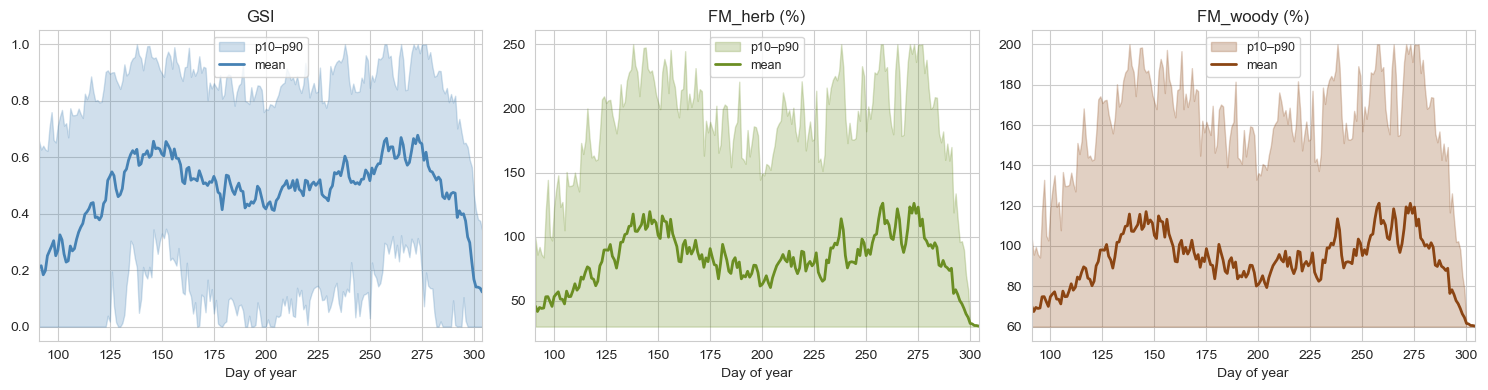

In [7]:
# Seasonal climatology of GSI and live FM
live_clim = (
    rtma_live.assign(doy=pd.to_datetime(rtma_live["date"]).dt.dayofyear)
             .groupby("doy")[["gsi", "FM_herb", "FM_woody"]]
             .agg(["mean", lambda x: x.quantile(0.10), lambda x: x.quantile(0.90)])
)
live_clim.columns = ["_".join(c).replace("<lambda_0>", "p10").replace("<lambda_1>", "p90")
                     for c in live_clim.columns]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, var, title, color in zip(
    axes,
    ["gsi", "FM_herb", "FM_woody"],
    ["GSI", "FM_herb (%)", "FM_woody (%)"],
    ["steelblue", "olivedrab", "saddlebrown"],
):
    ax.fill_between(
        live_clim.index,
        live_clim[f"{var}_p10"],
        live_clim[f"{var}_p90"],
        alpha=0.25, color=color, label="p10–p90",
    )
    ax.plot(live_clim.index, live_clim[f"{var}_mean"], color=color, lw=2, label="mean")
    ax.set_xlabel("Day of year")
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.set_xlim(91, 304)

plt.tight_layout()
os.makedirs(projdir / "figures", exist_ok=True)
plt.savefig(projdir / 'figures/RTMA_LiveFM_GSI_Time-series.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Join dead + live into daily frame

In [8]:
rtma_daily = rtma_peak.merge(
    rtma_live[["pyrome_id", "date", "gsi", "FM_herb", "FM_woody"]],
    on=["pyrome_id", "date"],
    how="left",
)

print(f"Daily frame shape : {rtma_daily.shape}")
print(f"Null FM_herb rows : {rtma_daily['FM_herb'].isnull().sum()}")
rtma_daily.head(3)

Daily frame shape : (37956, 12)
Null FM_herb rows : 0


,pyrome_id,date,doy,FM1,FM10,FM100,tmp_f,rh_pct,pcp_mm_hr,gsi,FM_herb,FM_woody
0,14,2011-04-01,91,16.765120,19.579733,19.810275,41.684544,76.064652,0.0,0.312706,30.0,60.0
1,14,2011-04-02,92,15.462139,21.630736,20.661246,34.405709,71.153816,0.123982,0.000000,30.0,60.0
2,14,2011-04-03,93,12.773914,15.832614,19.600050,31.842139,61.88994,0.0,0.000000,30.0,60.0


In [9]:
# Optional: cache to parquet so we don't re-run the lag on every notebook run
parquet_path = OUT_DIR / "rtma_daily_fm.parquet"
rtma_daily.to_parquet(parquet_path, index=False)
print(f"Saved → {parquet_path}")

# To reload without re-running the lag:
# rtma_daily = pd.read_parquet(parquet_path)

Saved → /Users/mcc/Library/CloudStorage/Box-Box/MCC/fire_modeling/FM_PythonWrapper/data/weather/flammap_rtma/rtma_daily_fm.parquet


## 6. QA validation

Checks:
- FM ordering: FM1 < FM10 (peak-hour fine fuels drier than 10-hr)
- FM10 < FM100 on average (lag integration)
- Spring (Apr) wetter than summer (Jul–Aug) for FM100
- Precip rebound visible in FM100 time series

In [10]:
# ── QA 1: FM ordering check ─────────────────────────────────────────────────
fm_order_ok = (
    (rtma_daily["FM1"] <= rtma_daily["FM10"]).mean() * 100,
    (rtma_daily["FM10"] <= rtma_daily["FM100"]).mean() * 100,
)
print(f"FM1 ≤ FM10 on  {fm_order_ok[0]:.1f}% of days  (expect high — peak-hour fine fuels driest)")
print(f"FM10 ≤ FM100 on {fm_order_ok[1]:.1f}% of days  (expect high — lag integrates wetter periods)")

# ── QA 2: seasonal means by month ───────────────────────────────────────────
seasonal = (
    rtma_daily.assign(month=pd.to_datetime(rtma_daily["date"]).dt.month)
              .groupby("month")[["FM1", "FM10", "FM100"]]
              .mean()
              .round(2)
)
print("\nMonthly mean FM (all pyromes):")
seasonal.index = ["Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct"][:len(seasonal)]
print(seasonal.to_string())

FM1 ≤ FM10 on  98.0% of days  (expect high — peak-hour fine fuels driest)
FM10 ≤ FM100 on 69.8% of days  (expect high — lag integrates wetter periods)

Monthly mean FM (all pyromes):
      FM1   FM10  FM100
Apr  8.32  11.54  12.32
May  7.92  11.73  12.97
Jun  6.07   9.73  11.20
Jul  6.00  10.23  11.52
Aug  6.20  10.40  11.93
Sep  6.53  10.20  11.16
Oct  8.09  11.47  12.17


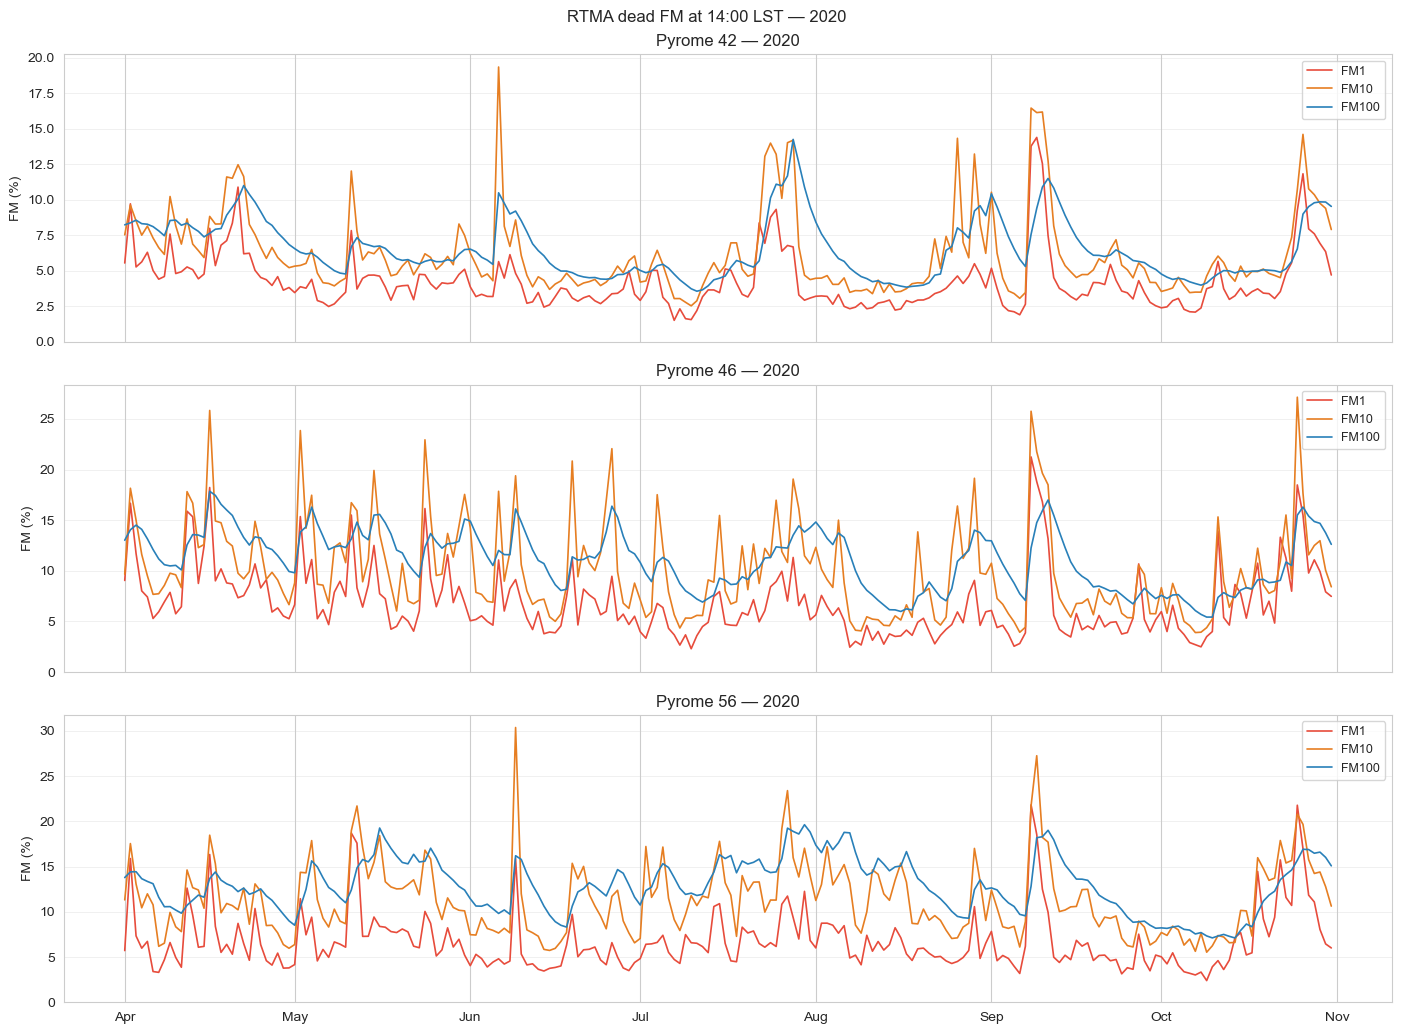

In [11]:
# ── QA 3: time-series plot for select pyromes — 2020 fire season ─────────────
PLOT_PYROMES = [42, 46, 56]   # range of pyromes — adjust as needed
PLOT_YEAR    = 2020

plot_df = rtma_daily[
    (rtma_daily["pyrome_id"].isin(PLOT_PYROMES))
    & (pd.to_datetime(rtma_daily["date"]).dt.year == PLOT_YEAR)
].copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])

fig, axes = plt.subplots(len(PLOT_PYROMES), 1, figsize=(14, 3.5 * len(PLOT_PYROMES)),
                          sharex=True)
colors = {"FM1": "#e74c3c", "FM10": "#e67e22", "FM100": "#2980b9"}

for ax, pid in zip(axes, PLOT_PYROMES):
    sub = plot_df[plot_df["pyrome_id"] == pid]
    for col, c in colors.items():
        ax.plot(sub["date"], sub[col], color=c, lw=1.2, label=col)
    ax.set_ylabel("FM (%)")
    ax.set_title(f"Pyrome {pid} — {PLOT_YEAR}")
    ax.legend(loc="upper right", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.set_ylim(0, None)
    ax.grid(axis="y", lw=0.4, alpha=0.5)

fig.suptitle(f"RTMA dead FM at 14:00 LST — {PLOT_YEAR}", fontsize=12)
plt.tight_layout()
plt.show()

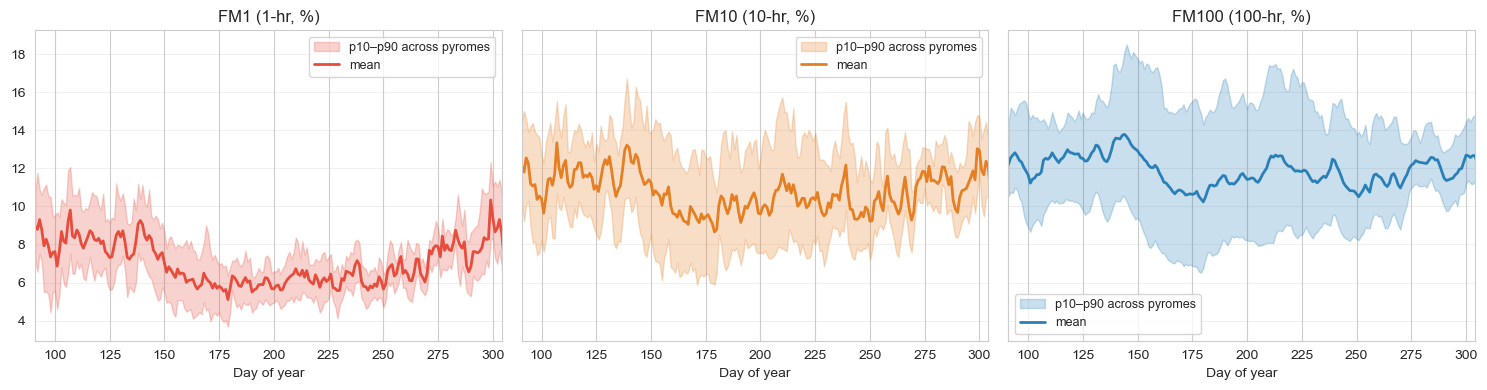

In [12]:
# ── QA 4: seasonal climatology by DOY — all pyromes, with IQR band ──────────
clim = (
    rtma_daily.assign(doy=pd.to_datetime(rtma_daily["date"]).dt.dayofyear)
              .groupby(["pyrome_id", "doy"])[["FM1", "FM10", "FM100"]]
              .mean()
              .groupby("doy")
              .agg(["mean",
                    lambda x: x.quantile(0.10),
                    lambda x: x.quantile(0.90)])
)
clim.columns = ["_".join(c).replace("<lambda_0>", "p10").replace("<lambda_1>", "p90")
                for c in clim.columns]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, var, color, title in zip(
    axes,
    ["FM1", "FM10", "FM100"],
    ["#e74c3c", "#e67e22", "#2980b9"],
    ["FM1 (1-hr, %)", "FM10 (10-hr, %)", "FM100 (100-hr, %)"],
):
    ax.fill_between(
        clim.index, clim[f"{var}_p10"], clim[f"{var}_p90"],
        alpha=0.25, color=color, label="p10–p90 across pyromes",
    )
    ax.plot(clim.index, clim[f"{var}_mean"], color=color, lw=2, label="mean")
    ax.set_xlabel("Day of year")
    ax.set_title(title)
    ax.set_xlim(91, 304)
    # ax.set_ylim(0, None)
    ax.legend(fontsize=9)
    ax.grid(axis="y", lw=0.4, alpha=0.5)

plt.tight_layout()
os.makedirs(projdir / "figures", exist_ok=True)
plt.savefig(projdir / 'figures/RTMA_DeadFM_Time-series.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# ── QA 5: precip rebound check ───────────────────────────────────────────────
# On wet days (pcp > 0.25 mm/hr at peak hour) FM100 should be notably higher
# than the rolling average, confirming the 'stall' precip handling is active.
wet_mask = rtma_daily["pcp_mm_hr"] > 0.25
print(f"Wet peak-hour days : {wet_mask.sum():,} of {len(rtma_daily):,} ({wet_mask.mean()*100:.1f}%)")
print("\nMean FM on wet vs dry peak-hour days:")
print(
    rtma_daily.groupby(wet_mask)[["FM1", "FM10", "FM100"]]
              .mean()
              .rename(index={False: "Dry", True: "Wet"})
              .round(2)
)

Wet peak-hour days : 3,536 of 37,956 (9.3%)

Mean FM on wet vs dry peak-hour days:
            FM1   FM10  FM100
pcp_mm_hr                    
Dry        6.79   9.95  11.28
Wet        9.28  18.72  17.98


## 7. FlamMap scenario cache

- **ERC percentile bands**: GridMET-driven (unchanged contract).
- **Dead FM (FM1/FM10/FM100)**: RTMA-derived medians on the ERC-band days (`dead_fm_source="rtma"`).
- **Live FM (FM_herb/FM_woody)**: **dead-FM scaling** (`live_fm_source="gridmet"` →
  `calc_live_fm_from_dead(FM100)`), NOT the §4 GSI values. GSI live FM is phenological and
  comes out non-monotonic when binned by ERC (see the §7 build-cell comment); dead-FM scaling
  gives the expected monotonic decrease toward the driest p97. §4 GSI FM is diagnostic only.
- **Wind speed/direction**: HRRR wind-cell cache + `wind_direction=-2` (downhill).

> **Prerequisites (this section only).** Sections 1–6 run on the RTMA CSVs alone. This
> section additionally needs, for the InterWest pyrome set:
> 1. the **GridMET ERC** export → `GRIDMET_CSV` (from `00a_gridMET-ERC.ipynb`), and
> 2. the **HRRR wind** cell caches in `WIND_DIR` (`pyrome_{id}_wind.json` for all 12
>    pyromes, from `00c_HRRR_WindCells.ipynb`).
>
> If either is missing the cells below will raise / return empty — build them first.

In [14]:
# Load GridMET (columns auto-lowercased — PYROME → pyrome)
gridmet = load_gridmet_csv(GRIDMET_CSV)
print("GridMET columns :", list(gridmet.columns))
print(f"Pyromes          : {sorted(gridmet['pyrome'].unique())}")
gridmet.head(2)

  [load_gridmet_csv] 41,088 rows, 12 pyromes, years 2010–2025  [percentile-suffix (tail=50)]
GridMET columns : ['pyrome', 'date', 'year', 'doy', 'system:index', 'vpd', 'erc', 'fm100', 'fm1000', 'rmin', 'rmax', 'pr', 'tmmx_f', 'tmmn_f', 'vpd_pa', 'ws_mph', 'wd_deg']
Pyromes          : [np.int64(14), np.int64(16), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(52), np.int64(53), np.int64(56), np.int64(128)]


,pyrome,date,year,doy,system:index,vpd,erc,fm100,fm1000,rmin,rmax,pr,tmmx_f,tmmn_f,vpd_pa,ws_mph,wd_deg
0,14,2010-04-01,2010,91,0_0000000000000000000d,0.229589,20.647516,16.651316,18.714206,37.173761,85.910655,1.049563,35.055849,14.117959,229.589438,7.160651,205.001205
1,16,2010-04-01,2010,91,0_0000000000000000000f,0.290092,26.352950,16.027191,18.158448,39.203627,86.628667,0.000000,42.421166,23.132578,290.091852,7.184894,196.997498


In [15]:
# Load HRRR wind percentiles from pre-built wind-cell JSONs
wind_pcts = wind_percentiles_from_cell_cache(WIND_DIR)
print(f"Wind pyromes loaded : {sorted(wind_pcts.keys())}")

# Preview one entry
sample_key = str(PYROME_IDS[0])
print(f"\nPyrome {sample_key} wind speeds (mph):")
if sample_key in wind_pcts:
    print({k: round(v, 1) for k, v in wind_pcts[sample_key]["ws_mph"].items()})

  [wind_percentiles_from_cell_cache] 12 pyromes × 5 percentiles
Wind pyromes loaded : ['128', '14', '16', '42', '43', '44', '45', '46', '47', '52', '53', '56']

Pyrome 42 wind speeds (mph):
{'p25': 7.8, 'p50': 12.0, 'p75': 16.2, 'p90': 19.9, 'p97': 24.6}


In [16]:
# live_fm_source="gridmet" → live FM from dead-FM scaling (calc_live_fm_from_dead),
# NOT the GSI path. GSI live FM (§4) is phenological: it drops to the dormant
# floor when COLD (Apr/Oct) and again when HOT/DRY (mid-summer), then greens up
# in September — so binning GSI FM by ERC percentile is NON-monotonic (e.g. p25
# herb can read lower than p50; p90 higher than p97). Dead-FM scaling ties live
# FM to FM100, which orders with ERC, giving the expected monotonic decrease
# toward the driest p97. Dead FM stays RTMA-sourced. (§4 GSI FM is kept for
# diagnostics/QA only; it does NOT feed the scenario cache.)
scenarios = build_flammap_scenario_cache(
    gridmet,
    pyrome_col="pyrome",
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.97],
    lat_deg=LAT_BY_PYROME,      # per-pyrome centroid latitude (was scalar CO_LAT)
    wind_percentiles=wind_pcts,
    wind_direction=-2,          # FlamMap downhill convention
    dead_fm_source="rtma",
    live_fm_source="rtma",   # dead-FM scaling (monotonic); GSI is non-monotonic vs ERC
    rtma_daily_df=rtma_daily,
    rtma_pyrome_col="pyrome_id",
    rtma_date_col="date",
    out_dir=OUT_DIR,
)

print(f"\nScenario cache written → {OUT_DIR}")
print(f"Pyromes: {list(scenarios.keys())}")

  [build_fm_timeseries] lag re-spun up over 16 contiguous segments (gaps > 45 days break the integration)
  [gridmet] Wrote pyrome_14_flammap.json
  [build_fm_timeseries] lag re-spun up over 16 contiguous segments (gaps > 45 days break the integration)
  [gridmet] Wrote pyrome_16_flammap.json
  [build_fm_timeseries] lag re-spun up over 16 contiguous segments (gaps > 45 days break the integration)
  [gridmet] Wrote pyrome_42_flammap.json
  [build_fm_timeseries] lag re-spun up over 16 contiguous segments (gaps > 45 days break the integration)
  [gridmet] Wrote pyrome_43_flammap.json
  [build_fm_timeseries] lag re-spun up over 16 contiguous segments (gaps > 45 days break the integration)
  [gridmet] Wrote pyrome_44_flammap.json
  [build_fm_timeseries] lag re-spun up over 16 contiguous segments (gaps > 45 days break the integration)
  [gridmet] Wrote pyrome_45_flammap.json
  [build_fm_timeseries] lag re-spun up over 16 contiguous segments (gaps > 45 days break the integration)
  [gridmet] 

In [17]:
# Spot-check: print scenario table for one pyrome
SPOT_PYROME = "46"
spot = scenarios[SPOT_PYROME]["scenarios"]
cols = ["FM_1hr", "FM_10hr", "FM_100hr", "FM_herb", "FM_woody", "WIND_SPEED", "erc_center"]
rows = []
for pkey, vals in spot.items():
    rows.append({"pct": pkey, **{c: vals.get(c) for c in cols}})
spot_df = pd.DataFrame(rows).set_index("pct")
print(f"\nPyrome {SPOT_PYROME} RTMA scenarios:")
print(spot_df.to_string())


Pyrome 46 RTMA scenarios:
     FM_1hr  FM_10hr  FM_100hr  FM_herb  FM_woody  WIND_SPEED  erc_center
pct                                                                      
p25     8.9     13.6      14.0    138.4     129.0         8.1        38.0
p50     6.6     10.0      12.5     89.9      98.1        12.3        48.4
p75     5.1      8.4      10.9     70.2      85.6        17.0        59.6
p90     4.5      7.6       9.7     49.2      72.2        21.5        68.0
p97     3.9      6.1       7.9     30.0      60.0        27.0        75.0


In [18]:
# ── Compare RTMA vs GridMET baseline FM for the same pyrome ──────────────────
baseline_path = BASELINE_DIR / f"pyrome_{SPOT_PYROME}_flammap.json"
if baseline_path.exists():
    with open(baseline_path) as f:
        baseline = json.load(f)["scenarios"]

    fm_cols = ["FM_1hr", "FM_10hr", "FM_100hr", "FM_herb", "FM_woody"]
    comparison_rows = []
    for pkey in sorted(spot.keys()):
        if pkey not in baseline:
            continue
        row = {"pct": pkey}
        for c in fm_cols:
            row[f"{c}_rtma"]    = round(spot[pkey].get(c, float("nan")), 1)
            row[f"{c}_gridmet"] = round(baseline[pkey].get(c, float("nan")), 1)
            row[f"{c}_delta"]   = round(
                row[f"{c}_rtma"] - row[f"{c}_gridmet"], 1
            )
        comparison_rows.append(row)

    comp = pd.DataFrame(comparison_rows).set_index("pct")
    print(f"Pyrome {SPOT_PYROME} — RTMA vs GridMET FM delta (RTMA − GridMET):")
    delta_cols = [f"{c}_delta" for c in fm_cols]
    print(comp[delta_cols].to_string())
else:
    print(f"No baseline JSON found at {baseline_path} — skipping comparison.")

Pyrome 46 — RTMA vs GridMET FM delta (RTMA − GridMET):
     FM_1hr_delta  FM_10hr_delta  FM_100hr_delta  FM_herb_delta  FM_woody_delta
pct                                                                            
p25           2.8            0.4            -9.0          -10.8           -71.0
p50           1.7            0.8            -3.9          -16.9           -49.8
p75           1.0            0.7            -0.8           -5.8           -19.7
p90           1.0            0.8             0.3          -11.8           -12.3
p97           1.0            0.3             0.7          -16.8            -4.8


## 8. Summary table

Per-pyrome FM at p50 (median danger) and p90 (high danger) scenarios.

In [19]:
fm_cols = ["FM_1hr", "FM_10hr", "FM_100hr", "FM_herb", "FM_woody"]
summary_rows = []
for pid, cache in scenarios.items():
    for pkey in ["p90", "p97"]:
        if pkey not in cache.get("scenarios", {}):
            continue
        vals = cache["scenarios"][pkey]
        row = {"pyrome": int(pid), "pct": pkey}
        for c in fm_cols:
            row[c] = round(vals.get(c, float("nan")), 1)
        summary_rows.append(row)

summary = (
    pd.DataFrame(summary_rows)
      .sort_values(["pct", "pyrome"])
      .set_index(["pct", "pyrome"])
)
print(f"RTMA-based FlamMap scenario FM — {REGION} pyromes")
print(summary.to_string())

RTMA-based FlamMap scenario FM — InterWest pyromes
            FM_1hr  FM_10hr  FM_100hr  FM_herb  FM_woody
pct pyrome                                              
p90 14         4.9      7.1       8.1     31.9      61.2
    16         4.4      6.5       7.3     30.0      60.0
    42         3.1      4.5       5.0     30.0      60.0
    43         3.6      5.0       5.9     30.0      60.0
    44         4.2      5.5       6.3     48.0      71.4
    45         4.6      6.7       7.9    101.0     105.2
    46         4.5      7.6       9.7     49.2      72.2
    47         4.3      6.4       7.5     46.2      70.3
    52         3.8      6.8       8.8     30.0      60.0
    53         4.4      7.3      10.0     30.0      60.0
    56         4.6      8.3      10.6     30.0      60.0
    128        3.7      6.0       6.9     30.0      60.0
p97 14         4.4      6.4       7.0     30.0      60.0
    16         4.0      5.8       6.3     30.0      60.0
    42         2.6      3.8       4.1

## 9. Formal comparison: RAWS (FireFamilyPlus) vs RTMA scenarios

> **Scope:** validates only the **Colorado** pyromes in the InterWest set (the RAWS
> reference stations are all in the Denver Water South Platte watershed). The R4
> pyromes (14, 16, 44) have no station table here — validate those separately against
> UT/ID RAWS if needed.

**Reference:** Rhea et al. (2024) CFRI-2414, Table 1.
Seven RAWS stations in the Denver Water South Platte watershed, CO.
Percentiles derived with FireFamilyPlus 5 from daily 1300 LST observations, 2000–2020.
**ERC percentile convention:** higher = drier conditions = lower FM.

| Aspect | RAWS / FireFamilyPlus | RTMA / this model |
|---|---|---|
| Input | Daily 1300 LST RAWS obs | Hourly pyrome-mean RTMA |
| Spatial scale | Single point | Pyrome-mean (thousands km²) |
| FM lag dt | 24 hr | 1 hr |
| ERC source | NFDRS78 from RAWS | GridMET GEE |
| Period | 2000–2020 | 2011–2025 |

Pyrome-mean spatial averaging is the primary driver of compressed FM variability
relative to point RAWS observations.

In [20]:
# ── Table 1 from Rhea et al. (2024) CFRI-2414 ─────────────────────────────
# Columns: station, erc_pct (25/50/90/97), FM1, FM10, FM100, FM_herb, FM_woody
TABLE1_ROWS = [
    # Harbison Meadow (Clear Creek area → pyrome 42)
    ("Harbison Meadow", 42, 25,  9.1, 10.7, 17.2,  96, 121),
    ("Harbison Meadow", 42, 50,  5.6,  7.4, 14.6,  40,  78),
    ("Harbison Meadow", 42, 90,  3.0,  4.7, 10.5,  30,  70),
    ("Harbison Meadow", 42, 97,  2.2,  3.8,  8.9,  30,  70),
    # Gunsight (Pike NF → pyrome 43)
    ("Gunsight",        43, 25,  7.9,  9.0, 13.5,  56,  92),
    ("Gunsight",        43, 50,  4.8,  6.0, 10.1,  35,  63),
    ("Gunsight",        43, 90,  2.3,  3.3,  5.9,  30,  60),
    ("Gunsight",        43, 97,  0.7,  1.4,  3.6,  30,  60),
    # Soda Creek (Pike NF area → pyrome 43)
    ("Soda Creek",      43, 25,  8.8, 10.1, 15.8,  62, 102),
    ("Soda Creek",      43, 50,  5.1,  6.7, 12.3,  35,  70),
    ("Soda Creek",      43, 90,  2.8,  4.0,  7.6,  30,  70),
    ("Soda Creek",      43, 97,  2.0,  3.2,  6.4,  30,  70),
    # Corral Creek (→ pyrome 45)
    ("Corral Creek",    45, 25,  8.9,  9.9, 14.6,  52,  97.1),
    ("Corral Creek",    45, 50,  5.5,  6.8, 11.6,  30,  70),
    ("Corral Creek",    45, 90,  2.7,  3.9,  7.5,  30,  70),
    ("Corral Creek",    45, 97,  1.7,  3.0,  6.2,  30,  70),
    # Pickle Gulch (Clear Creek drainage → pyrome 42)
    ("Pickle Gulch",    42, 25, 10.5, 11.1, 15.1,  49,  93),
    ("Pickle Gulch",    42, 50,  5.9,  7.2, 11.4,  30,  70),
    ("Pickle Gulch",    42, 90,  2.9,  4.0,  7.1,  30,  70),
    ("Pickle Gulch",    42, 97,  2.0,  3.1,  5.8,  30,  70),
    # Jones Hill (→ pyrome 43)
    ("Jones Hill",      43, 25,  7.6,  8.8, 13.6,  48,  79),
    ("Jones Hill",      43, 50,  4.9,  6.0, 10.2,  30,  60),
    ("Jones Hill",      43, 90,  2.3,  3.3,  6.3,  30,  60),
    ("Jones Hill",      43, 97,  1.6,  2.5,  5.1,  30,  60),
    # Cheesman (Cheesman Reservoir, Douglas Co → pyrome 43)
    ("Cheesman",        43, 25,  6.6,  7.7, 21.0,  51,  90),
    ("Cheesman",        43, 50,  4.1,  5.3, 17.6,  30,  63),
    ("Cheesman",        43, 90,  1.7,  2.8, 13.7,  30,  60),
    ("Cheesman",        43, 97,  1.1,  2.1, 11.8,  30,  60),
]

raws_df = pd.DataFrame(
    TABLE1_ROWS,
    columns=["station", "pyrome", "erc_pct", "FM1_raws", "FM10_raws",
             "FM100_raws", "FMherb_raws", "FMwoody_raws"],
)
print(f"Table 1 rows: {len(raws_df)} (7 stations × 4 percentiles)")
print(f"Note: station-to-pyrome mapping is approximate (geography-based).")
print(f"      Cheesman FM100 is notably higher — likely elevation/microclimate effect.")
raws_df.head(8)

Table 1 rows: 28 (7 stations × 4 percentiles)
Note: station-to-pyrome mapping is approximate (geography-based).
      Cheesman FM100 is notably higher — likely elevation/microclimate effect.


,station,pyrome,erc_pct,FM1_raws,FM10_raws,FM100_raws,FMherb_raws,FMwoody_raws
0,Harbison Meadow,42,25,9.1,10.7,17.2,96,121.0
1,Harbison Meadow,42,50,5.6,7.4,14.6,40,78.0
2,Harbison Meadow,42,90,3.0,4.7,10.5,30,70.0
3,Harbison Meadow,42,97,2.2,3.8,8.9,30,70.0
4,Gunsight,43,25,7.9,9.0,13.5,56,92.0
5,Gunsight,43,50,4.8,6.0,10.1,35,63.0
6,Gunsight,43,90,2.3,3.3,5.9,30,60.0
7,Gunsight,43,97,0.7,1.4,3.6,30,60.0


In [21]:
# ── Load RTMA scenario cache (written by Sec 7) ────────────────────────────
COMPARE_PYROMES = [42, 43, 45]   # pyromes containing the 7 RAWS stations
PCT_MAP = {25: "p25", 50: "p50", 90: "p90", 97: "p97", 99: "p99"}
FM_KEY_MAP = {
    "FM1_rtma":    "FM_1hr",
    "FM10_rtma":   "FM_10hr",
    "FM100_rtma":  "FM_100hr",
    "FMherb_rtma": "FM_herb",
    "FMwoody_rtma":"FM_woody",
}

rtma_rows = []
for pid in COMPARE_PYROMES:
    cache_path = OUT_DIR / f"pyrome_{pid}_flammap.json"
    if not cache_path.exists():
        print(f"  WARNING: {cache_path.name} not found — run Sec 7 first")
        continue
    with open(cache_path) as f:
        cache = json.load(f)
    scen = cache.get("scenarios", {})
    for erc_pct, pkey in PCT_MAP.items():
        if pkey not in scen:
            continue
        s = scen[pkey]
        rtma_rows.append({
            "pyrome":       pid,
            "erc_pct":      erc_pct,
            "FM1_rtma":     s.get("FM_1hr"),
            "FM10_rtma":    s.get("FM_10hr"),
            "FM100_rtma":   s.get("FM_100hr"),
            "FMherb_rtma":  s.get("FM_herb"),
            "FMwoody_rtma": s.get("FM_woody"),
        })

rtma_scen_df = pd.DataFrame(rtma_rows)
print(f"RTMA scenario rows loaded: {len(rtma_scen_df)}")
rtma_scen_df

RTMA scenario rows loaded: 12


,pyrome,erc_pct,FM1_rtma,FM10_rtma,FM100_rtma,FMherb_rtma,FMwoody_rtma
0,42,25,6.4,9.6,10.8,51.8,73.9
1,42,50,4.6,6.7,8.1,33.0,61.9
2,42,90,3.1,4.5,5.0,30.0,60.0
3,42,97,2.6,3.8,4.1,30.0,60.0
4,43,25,7.2,10.5,11.2,96.9,102.6
5,43,50,5.0,7.3,9.2,57.8,77.7
6,43,90,3.6,5.0,5.9,30.0,60.0
7,43,97,3.0,4.3,4.8,30.0,60.0
8,45,25,9.5,12.8,13.7,33.5,62.2
9,45,50,7.1,10.0,12.0,102.1,105.9


In [22]:
# ── Comparison table: RAWS vs RTMA with delta ─────────────────────────────
comp = raws_df.merge(rtma_scen_df, on=["pyrome", "erc_pct"], how="left")

for var in ["FM1", "FM10", "FM100"]:
    comp[f"{var}_delta"] = (comp[f"{var}_rtma"] - comp[f"{var}_raws"]).round(1)

display_cols = [
    "station", "pyrome", "erc_pct",
    "FM1_raws",  "FM1_rtma",  "FM1_delta",
    "FM10_raws", "FM10_rtma", "FM10_delta",
    "FM100_raws","FM100_rtma","FM100_delta",
]
print("RAWS (FireFamilyPlus) vs RTMA (NFDRS78 hourly lag) — delta = RTMA − RAWS")
print("Positive delta → RTMA wetter; negative → RTMA drier\n")
# comp[display_cols].to_string(index=False)

RAWS (FireFamilyPlus) vs RTMA (NFDRS78 hourly lag) — delta = RTMA − RAWS
Positive delta → RTMA wetter; negative → RTMA drier



In [23]:
# ── Mean delta by ERC percentile ──────────────────────────────────────────
delta_cols = ["FM1_delta", "FM10_delta", "FM100_delta"]
delta_summary = (
    comp.groupby("erc_pct")[delta_cols]
        .agg(["mean", "min", "max"])
        .round(1)
)
print("Mean delta (RTMA − RAWS) by ERC percentile — across all matched stations:")
print(delta_summary.to_string())
print("\nPositive = RTMA wetter, negative = RTMA drier.")
print("Expect RTMA to be slightly wetter (spatially averaged) especially at low ERC,")
print("and possibly drier at extreme ERC (pyrome-mean smooths point extremes).")

Mean delta (RTMA − RAWS) by ERC percentile — across all matched stations:
        FM1_delta           FM10_delta           FM100_delta          
             mean  min  max       mean  min  max        mean  min  max
erc_pct                                                               
25           -1.2 -4.1  0.6        1.0 -1.5  2.9        -4.4 -9.8 -0.9
50            0.1 -1.3  1.6        1.0 -0.7  3.2        -3.3 -8.4  0.4
90            1.1  0.1  1.9        1.4 -0.2  2.8        -2.4 -7.8  0.4
97            1.4  0.4  2.3        1.6  0.0  2.9        -2.0 -7.0  1.2

Positive = RTMA wetter, negative = RTMA drier.
Expect RTMA to be slightly wetter (spatially averaged) especially at low ERC,
and possibly drier at extreme ERC (pyrome-mean smooths point extremes).


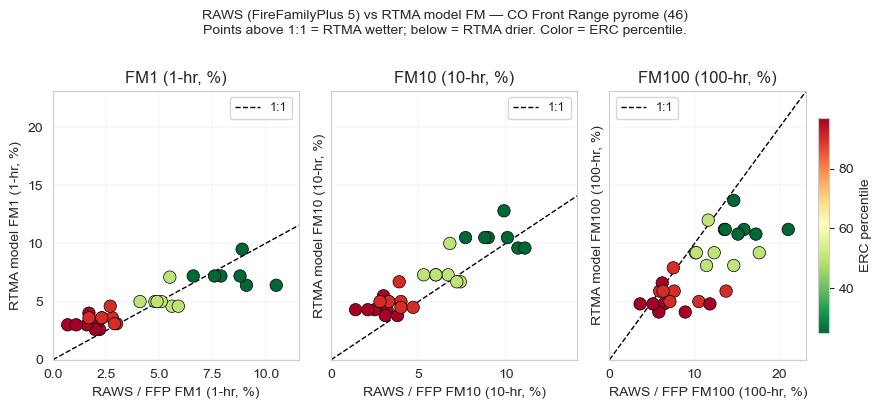

In [24]:
# ── Scatter plot: RAWS FM vs RTMA FM ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(9,4), sharey=True)

var_pairs = [
    ("FM1_raws",   "FM1_rtma",   "FM1 (1-hr, %)",   "#e74c3c"),
    ("FM10_raws",  "FM10_rtma",  "FM10 (10-hr, %)",  "#e67e22"),
    ("FM100_raws", "FM100_rtma", "FM100 (100-hr, %)","#2980b9"),
]

for ax, (xc, yc, title, color) in zip(axes, var_pairs):
    sub = comp[[xc, yc, "erc_pct"]].dropna()
    scatter = ax.scatter(sub[xc], sub[yc], c=sub["erc_pct"],
                          cmap="RdYlGn_r", s=80, edgecolors="k", lw=0.5, zorder=3)
    # 1:1 line
    lim = max(sub[[xc, yc]].max()) * 1.1
    ax.plot([0, lim], [0, lim], "k--", lw=1, label="1:1")
    ax.set_xlabel(f"RAWS / FFP {title}")
    ax.set_ylabel(f"RTMA model {title}")
    ax.set_title(title)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.grid(lw=0.3, alpha=0.5)
    ax.legend(fontsize=9)

cbar = fig.colorbar(scatter, ax=axes[-1], shrink=0.8)
cbar.set_label("ERC percentile")
fig.suptitle(
    "RAWS (FireFamilyPlus 5) vs RTMA model FM — CO Front Range pyrome (46)\n"
    "Points above 1:1 = RTMA wetter; below = RTMA drier. Color = ERC percentile.",
    fontsize=10, y=1.01,
)
plt.tight_layout()
plt.savefig(projdir / 'figures/RTMA_RAWS_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### Testing


In [25]:
# Grab and build a FlamMap input file